In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os

# ⚙️ ADAPTER CE CHEMIN selon ta structure
RECORDING_PATH = '../data/train_p1_extracted/01_assy_0_1'

print("📂 Fichiers disponibles dans ce recording :")
for f in sorted(os.listdir(RECORDING_PATH)):
    size = os.path.getsize(os.path.join(RECORDING_PATH, f)) if os.path.isfile(os.path.join(RECORDING_PATH, f)) else '-'
    print(f"  {f:40s}  {size} bytes" if isinstance(size, int) else f"  📁 {f}/")

📂 Fichiers disponibles dans ce recording :
  AR_labels.csv                             5479 bytes
  OD_labels.json                            97112 bytes
  PSR_labels.csv                            361 bytes
  PSR_labels_raw.csv                        238 bytes
  PSR_labels_with_errors.csv                361 bytes
  📁 ambient_light/
  📁 depth/
  gaze.csv                                  35841 bytes
  hands.csv                                 753612 bytes
  pose.csv                                  132960 bytes
  📁 rgb/
  📁 stereo_left/
  📁 stereo_right/


### 1.1 — Lire les labels PSR (Procedure Step Recognition)

In [2]:
# Charger les labels avec erreurs
psr_path = os.path.join(RECORDING_PATH, 'PSR_labels_with_errors.csv')
df_psr = pd.read_csv(psr_path, header=None, names=['frame_name', 'step_id', 'step_name'])

print("=== STRUCTURE DU FICHIER PSR ===")
print(f"Colonnes : {list(df_psr.columns)}")
print(f"Nombre de frames : {len(df_psr)}")
print(f"Durée estimée : {len(df_psr)/15:.1f} secondes à 15fps")
print()
print("5 premières lignes :")
df_psr.head(10)

=== STRUCTURE DU FICHIER PSR ===
Colonnes : ['frame_name', 'step_id', 'step_name']
Nombre de frames : 9
Durée estimée : 0.6 secondes à 15fps

5 premières lignes :


,frame_name,step_id,step_name
0,000198.jpg,3,Install front chassis
1,000198.jpg,6,Install front chassis pin
2,000557.jpg,9,Install rear chassis
3,000557.jpg,15,Install front rear chassis pin
4,000631.jpg,18,Install rear rear chassis pin
5,000878.jpg,21,Install front bracket
6,000878.jpg,24,Install front bracket screw
7,001295.jpg,27,Install front wheel assy
8,001765.jpg,30,Install rear wheel assy


In [3]:
print(list(df_psr.columns))

['frame_name', 'step_id', 'step_name']


In [4]:
df_psr = pd.read_csv(psr_path, header=None, names=['frame_name', 'step_id', 'step_name'])

In [5]:
# Distribution des steps
print("=== COLONNES DISPONIBLES ===")
print(list(df_psr.columns))
print()

# Détecter automatiquement la colonne step
step_col = None
for candidate in ['step', 'step_id', 'label', 'action', 'class', 'category']:
    if candidate in df_psr.columns:
        step_col = candidate
        break

if step_col is None:
    # Prendre la première colonne non-numérique ou la deuxième colonne
    step_col = df_psr.columns[1]
    print(f"⚠️  Colonne 'step' non trouvée — utilisation de '{step_col}' à la place")

print(f"=== DISTRIBUTION DES STEPS (colonne: '{step_col}') ===")
print(df_psr[step_col].value_counts().sort_index())
print()

# Vérifier s'il y a une colonne erreur
error_cols = [c for c in df_psr.columns if 'error' in c.lower() or 'err' in c.lower()]
print(f"Colonnes liées aux erreurs : {error_cols}")

if error_cols:
    for col in error_cols:
        print(f"\n{col} :")
        print(df_psr[col].value_counts())

=== COLONNES DISPONIBLES ===
['frame_name', 'step_id', 'step_name']

=== DISTRIBUTION DES STEPS (colonne: 'step_id') ===
step_id
3     1
6     1
9     1
15    1
18    1
21    1
24    1
27    1
30    1
Name: count, dtype: int64

Colonnes liées aux erreurs : []


In [6]:
import os

RECORDING_PATH = '../data/train_p1_extracted/01_assy_0_1'

print("Tous les fichiers dans ce recording :")
for f in sorted(os.listdir(RECORDING_PATH)):
    if os.path.isfile(os.path.join(RECORDING_PATH, f)):
        size = os.path.getsize(os.path.join(RECORDING_PATH, f))
        print(f"  {f:45s}  {size:>10,} bytes")

Tous les fichiers dans ce recording :
  AR_labels.csv                                       5,479 bytes
  OD_labels.json                                     97,112 bytes
  PSR_labels.csv                                        361 bytes
  PSR_labels_raw.csv                                    238 bytes
  PSR_labels_with_errors.csv                            361 bytes
  gaze.csv                                           35,841 bytes
  hands.csv                                         753,612 bytes
  pose.csv                                          132,960 bytes


In [7]:
df_ar = pd.read_csv(os.path.join(RECORDING_PATH, 'AR_labels.csv'), header=None)
print(f"Shape : {df_ar.shape}")
print(df_ar.head(10))

Shape : (105, 5)
             0   1                  2           3           4
0  01_assy_0_1   0   take_short_brace  000028.jpg  000040.jpg
1  01_assy_0_1  30    fit_short_brace  000040.jpg  000055.jpg
2  01_assy_0_1   0   take_short_brace  000059.jpg  000063.jpg
3  01_assy_0_1  30    fit_short_brace  000063.jpg  000073.jpg
4  01_assy_0_1   1      align_objects  000072.jpg  000084.jpg
5  01_assy_0_1   2     take_pin_short  000089.jpg  000099.jpg
6  01_assy_0_1   1      align_objects  000100.jpg  000110.jpg
7  01_assy_0_1   3     plug_short_pin  000102.jpg  000120.jpg
8  01_assy_0_1   4  take_tooth_washer  000136.jpg  000143.jpg
9  01_assy_0_1  31   fit_tooth_washer  000143.jpg  000150.jpg


In [8]:
#CELLULE16
df_ar = pd.read_csv(os.path.join(RECORDING_PATH, 'AR_labels.csv'), header=None,
                    names=['recording', 'action_id', 'action_name', 'frame_start', 'frame_end'])

# Extraire les indices numériques
df_ar['start_idx'] = df_ar['frame_start'].str.replace('.jpg','').astype(int)
df_ar['end_idx']   = df_ar['frame_end'].str.replace('.jpg','').astype(int)

# Nombre total de frames
rgb_path = os.path.join(RECORDING_PATH, 'rgb')
total_frames = len(os.listdir(rgb_path))
print(f"Total frames RGB : {total_frames}")

# Créer un array label par frame — -1 = pas d'annotation
action_id_per_frame   = np.full(total_frames, -1, dtype=int)
action_name_per_frame = np.full(total_frames, 'background', dtype=object)

for _, row in df_ar.iterrows():
    start = row['start_idx']
    end   = row['end_idx']
    action_id_per_frame[start:end]   = row['action_id']
    action_name_per_frame[start:end] = row['action_name']

# Résultat final
df_labels = pd.DataFrame({
    'frame_idx'   : np.arange(total_frames),
    'action_id'   : action_id_per_frame,
    'action_name' : action_name_per_frame
})

print(f"\nShape final : {df_labels.shape}")
print(f"\nDistribution des actions :")
print(df_labels['action_name'].value_counts())
print(f"\nFrames sans annotation (background) : {(df_labels['action_id'] == -1).sum()}")

Total frames RGB : 1846

Shape final : (1846, 3)

Distribution des actions :
action_name
background            502
align_objects         153
plug_objects          117
check_instruction     101
take_nut               86
tighten_nut            81
plug_short_pin         54
fit_nut                51
take_tooth_washer      49
tighten_acorn_nut      46
take_wheel             46
fit_wheel              45
take_round_washer      45
take_pin_short         45
fit_tooth_washer       43
fit_round_washer       41
take_partial_model     35
take_long_brace        29
take_screw_pin         28
put_partial_model      27
fit_short_brace        24
take_pin_middle        22
fit_pulley             19
take_wing              19
take_short_brace       16
take_pin_long          14
fit_wing_beam          13
fit_long_brace         13
take_acorn_nut         12
take_pulley            11
take_wing_beam         10
plug_pin_long           9
browse_instruction      8
put_screw_pin           7
plug_screw_pin          6
p

In [9]:
# Vérifier synchronisation avec hands.csv
df_hands = pd.read_csv(os.path.join(RECORDING_PATH, 'hands.csv'))
print(f"Labels frames : {len(df_labels)}")
print(f"Hands frames  : {len(df_hands)}")
print(f"RGB frames    : {total_frames}")

# Les 3 doivent être égaux ou très proches
assert abs(len(df_labels) - len(df_hands)) < 10, "Désynchronisation trop grande"
print("✅ Synchronisation OK — prêt pour Step 2")

Labels frames : 1846
Hands frames  : 1844
RGB frames    : 1846
✅ Synchronisation OK — prêt pour Step 2


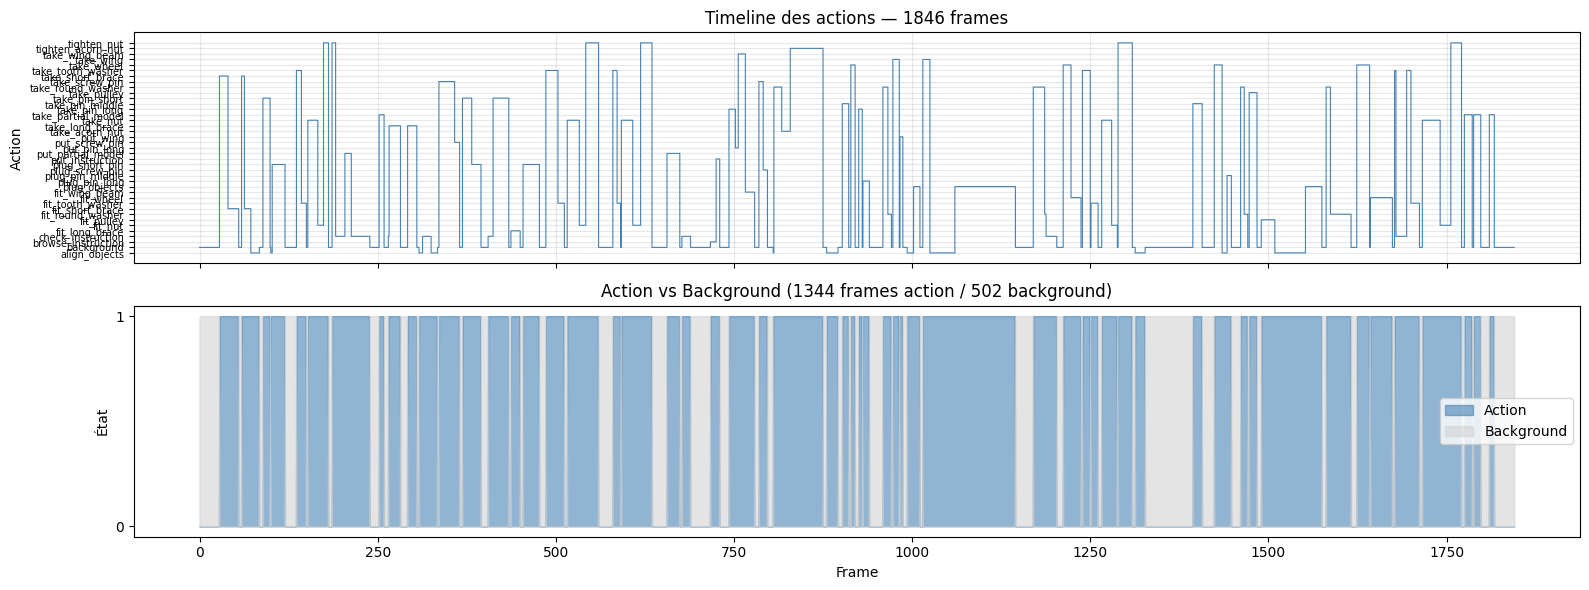

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(16, 6), sharex=True)

# ---- Axe 1 : Timeline frame par frame ----
# Encoder action_name → entier pour le plot
action_classes = df_labels['action_name'].unique().tolist()
action_to_idx  = {a: i for i, a in enumerate(sorted(action_classes))}
numeric_actions = df_labels['action_name'].map(action_to_idx).values

axes[0].step(df_labels['frame_idx'], numeric_actions, 
             color='steelblue', linewidth=0.8, where='post')
axes[0].set_yticks(range(len(action_classes)))
axes[0].set_yticklabels(sorted(action_classes), fontsize=7)
axes[0].set_ylabel('Action')
axes[0].set_title(f'Timeline des actions — {len(df_labels)} frames')
axes[0].grid(True, alpha=0.3)

# ---- Axe 2 : Background vs Action ----
is_background = (df_labels['action_name'] == 'background').astype(int)
is_action      = (df_labels['action_name'] != 'background').astype(int)

axes[1].fill_between(df_labels['frame_idx'], is_action, 
                     color='steelblue', alpha=0.6, label='Action')
axes[1].fill_between(df_labels['frame_idx'], is_background, 
                     color='lightgray', alpha=0.6, label='Background')
axes[1].set_ylabel('État')
axes[1].set_title(f'Action vs Background ({is_action.sum()} frames action / {is_background.sum()} background)')
axes[1].set_yticks([0, 1])
axes[1].legend()
axes[1].set_xlabel('Frame')

plt.tight_layout()
plt.show()

In [11]:
hands_path = os.path.join(RECORDING_PATH, 'hands.csv')
df_hands = pd.read_csv(hands_path)

print("=== STRUCTURE HANDS.CSV ===")
print(f"Colonnes : {list(df_hands.columns[:10])}... ({len(df_hands.columns)} total)")
print(f"Nombre de frames : {len(df_hands)}")
print()
print("5 premières lignes :")
df_hands.head()#CELLULE20

=== STRUCTURE HANDS.CSV ===
Colonnes : ['000000.jpg', '206', '491', '138', '564', '194', '531', '291', '497', '339']... (105 total)
Nombre de frames : 1844

5 premières lignes :


,000000.jpg,206,491,138,564,194,531,291,497,339,...,1016.1,564.1,970,486,920,482,909,507,918,521
0,000001.jpg,206,485,138,560,194,527,290,491,339,...,1012,560,964,483,912,478,901,503,909,518
1,000002.jpg,204,481,138,557,195,525,291,490,338,...,1025,555,988,474,938,464,912,485,901,501
2,000003.jpg,206,479,140,555,194,521,291,483,341,...,1022,555,981,475,929,467,905,487,895,503
3,000004.jpg,209,473,141,552,196,520,293,484,342,...,1027,553,986,475,935,467,916,490,915,506
4,000005.jpg,214,470,147,546,202,515,298,480,348,...,1031,552,989,475,938,468,919,491,920,505


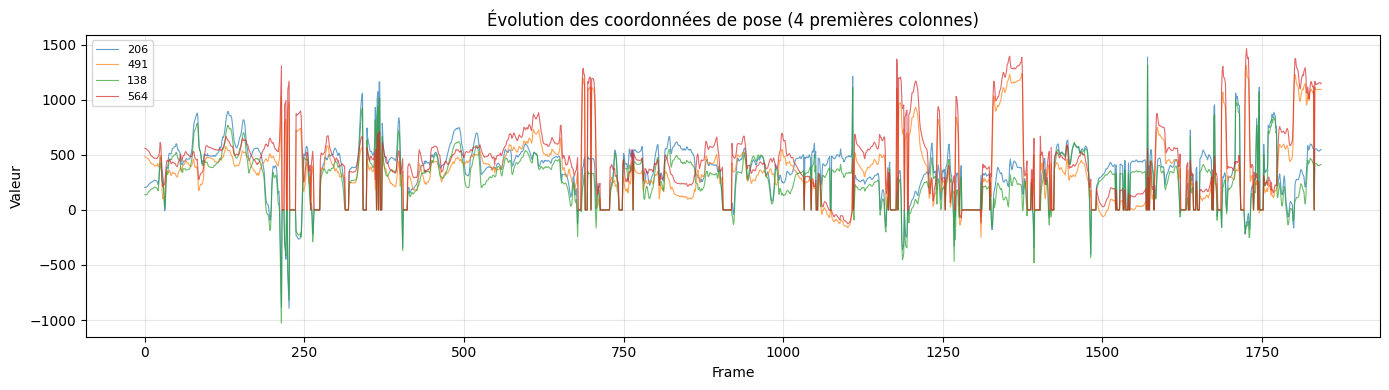


💡 Ce graphique montre le mouvement des mains dans le temps.
Les NaN = main hors champ. À interpoler ou à remplacer par des zéros.


In [12]:
# Visualiser un keypoint de la main dans le temps
# On prend la première colonne numérique disponible
numeric_cols = df_hands.select_dtypes(include=[np.number]).columns

fig, ax = plt.subplots(figsize=(14, 4))
for col in numeric_cols[:4]:  # 4 premières colonnes numériques
    ax.plot(df_hands[col].values, label=col, alpha=0.7, linewidth=0.8)

ax.set_title('Évolution des coordonnées de pose (4 premières colonnes)')
ax.set_xlabel('Frame')
ax.set_ylabel('Valeur')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()#CELLULE22
plt.show()

print("\n💡 Ce graphique montre le mouvement des mains dans le temps.")
print("Les NaN = main hors champ. À interpoler ou à remplacer par des zéros.")

In [13]:
# Vérifier les frames RGB
rgb_path = os.path.join(RECORDING_PATH, 'rgb')
if os.path.exists(rgb_path):
    frames_list = sorted(os.listdir(rgb_path))
    print(f"📸 Frames RGB disponibles : {len(frames_list)}")
    print(f"   Premier : {frames_list[0]}")
    print(f"   Dernier : {frames_list[-1]}")
    print(f"   Format  : {frames_list[0].split('.')[-1]}")
    
    # Vérifier cohérence avec labels
    if len(frames_list) == len(df_psr):
        print("✅ RGB frames = PSR frames — parfaitement synchronisé")
    else:
        print(f"⚠️ RGB: {len(frames_list)} vs PSR: {len(df_psr)} frames")
else:
    print("❌ Dossier rgb/ non trouvé — adapter le chemin RECORDING_PATH")

📸 Frames RGB disponibles : 1846
   Premier : 000000.jpg
   Dernier : Thumbs.db
   Format  : jpg
⚠️ RGB: 1846 vs PSR: 9 frames


In [14]:
# ============================================================
# FIX 1 — Filtrer Thumbs.db dans le comptage RGB
# ============================================================
rgb_path = os.path.join(RECORDING_PATH, 'rgb')
all_frames = sorted([
    f for f in os.listdir(rgb_path)
    if f.endswith(('.jpg', '.jpeg', '.png'))  # exclut Thumbs.db
])
total_frames = len(all_frames)
print(f"RGB frames réels : {total_frames}")  # doit donner 1845 ou 1846

# ============================================================
# FIX 2 — Synchronisation : on prend le minimum commun
# ============================================================
df_hands  = pd.read_csv(os.path.join(RECORDING_PATH, 'hands.csv'))
# df_labels vient de l'expand AR_labels qu'on a fait avant

n_sync = min(total_frames, len(df_hands), len(df_labels))
print(f"Frames synchronisées : {n_sync}")

# Tronquer tout au même n
df_labels_sync = df_labels.iloc[:n_sync].reset_index(drop=True)
df_hands_sync  = df_hands.iloc[:n_sync].reset_index(drop=True)
frames_sync    = all_frames[:n_sync]

print(f"✅ Tout synchronisé à {n_sync} frames")
print(f"   df_labels : {len(df_labels_sync)}")
print(f"   df_hands  : {len(df_hands_sync)}")
print(f"   RGB files : {len(frames_sync)}")

# ============================================================
# FIX 3 — Vérifier hands.csv : header ou pas ?
# ============================================================
print("\nHands.csv — premières colonnes :")
print(df_hands.columns[:5].tolist())
# Si les colonnes sont des chiffres genre '206', '491'...
# → pas de header, pandas a pris la 1ère ligne comme header
# Fix :
df_hands = pd.read_csv(
    os.path.join(RECORDING_PATH, 'hands.csv'),
    header=None  # ← ajouter si colonnes sont des nombres
)
print(f"Hands shape après fix : {df_hands.shape}")
# Doit être (1844, 105) — 105 colonnes = coordonnées des keypoints

RGB frames réels : 1845
Frames synchronisées : 1844
✅ Tout synchronisé à 1844 frames
   df_labels : 1844
   df_hands  : 1844
   RGB files : 1844

Hands.csv — premières colonnes :
['000000.jpg', '206', '491', '138', '564']
Hands shape après fix : (1845, 105)


In [26]:
# Vérifier que hands.csv démarre bien à la frame 0
# La première colonne de hands.csv est le nom de la frame
first_col = df_hands.columns[0]
print(f"Première frame dans hands.csv : {df_hands[first_col].iloc[0]}")
print(f"Première frame dans frames_sync : {frames_sync[0]}")
print(f"Première action dans df_labels  : {df_labels_sync.iloc[0]['action_name']}")

# Vérifier les 5 premières et 5 dernières
print("\n--- 5 premières lignes ---")
for t in [0, 1, 2, 3, 4]:
    rgb_f   = frames_sync[t]
    hands_f = df_hands_sync.iloc[t][df_hands_sync.columns[0]] if df_hands_sync.columns[0] == first_col else f"col_{t}"
    label   = df_labels_sync.iloc[t]['action_name']
    print(f"t={t:4d} | RGB: {rgb_f} | hands: {hands_f} | label: {label}")

print("\n--- 5 dernières lignes ---")
for t in range(len(frames_sync)-5, len(frames_sync)):
    rgb_f  = frames_sync[t]
    label  = df_labels_sync.iloc[t]['action_name']
    print(f"t={t:4d} | RGB: {rgb_f} | label: {label}")

Première frame dans hands.csv : 000000.jpg
Première frame dans frames_sync : 000000.jpg
Première action dans df_labels  : background

--- 5 premières lignes ---
t=   0 | RGB: 000000.jpg | hands: col_0 | label: background
t=   1 | RGB: 000001.jpg | hands: col_1 | label: background
t=   2 | RGB: 000002.jpg | hands: col_2 | label: background
t=   3 | RGB: 000003.jpg | hands: col_3 | label: background
t=   4 | RGB: 000004.jpg | hands: col_4 | label: background

--- 5 dernières lignes ---
t=1839 | RGB: 001839.jpg | label: background
t=1840 | RGB: 001840.jpg | label: background
t=1841 | RGB: 001841.jpg | label: background
t=1842 | RGB: 001842.jpg | label: background
t=1843 | RGB: 001843.jpg | label: background


In [15]:
# Inspecter les valeurs aberrantes
numeric_cols = df_hands.select_dtypes(include=[np.number]).columns
print(f"Valeurs < -100 (probables NaN déguisés) : {(df_hands[numeric_cols] < -100).sum().sum()}")
print(f"Valeurs == 0 (main non visible) : {(df_hands[numeric_cols] == 0).sum().sum()}")

# Fix — remplacer valeurs aberrantes par 0
df_hands_clean = df_hands.copy()
df_hands_clean[numeric_cols] = df_hands_clean[numeric_cols].apply(
    lambda col: col.where(col > -100, 0)  # tout < -100 → 0
)

Valeurs < -100 (probables NaN déguisés) : 1647
Valeurs == 0 (main non visible) : 26303


In [16]:
import subprocess
import sys

result = subprocess.run(
    [sys.executable, "-m", "pip", "install", "rerun-sdk"],
    capture_output=True, text=True
)
print(result.stdout[-500:] if result.stdout else "")
print(result.stderr[-200:] if result.stderr else "")
print("✅ Installation terminée" if result.returncode == 0 else "❌ Erreur installation")

mpy>=2 in c:\users\hp\miniconda3\envs\assembly-ai\lib\site-packages (from rerun-sdk) (2.2.6)


✅ Installation terminée


In [17]:
rerun cobot_step1.rrd

No lines in history match specification


In [18]:
import rerun as rr
print(rr.__version__)

0.31.3


In [24]:
import rerun as rr
import numpy as np
from PIL import Image

rr.init("cobot_assembly_step1")
rr.save("cobot_step1.rrd")

N_FRAMES_VISU = 200
numeric_cols = df_hands_sync.select_dtypes(include=[np.number]).columns

for t in range(min(N_FRAMES_VISU, len(frames_sync))):

    # --- Timeline — syntaxe correcte 0.31.x ---
    rr.set_time("frame", sequence=t)

    # --- Image RGB ---
    frame_path = os.path.join(rgb_path, frames_sync[t])
    img = np.array(Image.open(frame_path).convert("RGB"))
    rr.log("camera/rgb", rr.Image(img))

    # --- Keypoints mains ---
    pose_row = df_hands_sync.iloc[t][numeric_cols].values.astype(np.float32)
    pose_row = np.where(pose_row < -100, np.nan, pose_row)
    xs = pose_row[0::2]
    ys = pose_row[1::2]
    valid = ~(np.isnan(xs) | np.isnan(ys))
    if valid.any():
        points_2d = np.stack([xs[valid], ys[valid]], axis=1)
        rr.log("camera/hands", rr.Points2D(points_2d, radii=4))

    # --- Labels — Scalars (avec s) en 0.31.x ---
    action = df_labels_sync.iloc[t]['action_name']
    action_id = int(df_labels_sync.iloc[t]['action_id'])
    rr.log("labels/action_id", rr.Scalars(action_id))
    rr.log("labels/is_background", rr.Scalars(1 if action == "background" else 0))

print(f"✅ Fichier sauvegardé : cobot_step1.rrd")
print(f"   Lance dans ton terminal : rerun cobot_step1.rrd")

✅ Fichier sauvegardé : cobot_step1.rrd
   Lance dans ton terminal : rerun cobot_step1.rrd


 conda activate assembly-ai
>> rerun cobot_step1.rrd

In [25]:
import os
print(os.path.abspath("cobot_step1.rrd"))

c:\Users\HP\assembly-error-detection\notebooks\cobot_step1.rrd


### 1.3 — Résumé Step 1

Ce qu'on a compris :
- Structure complète : RGB frames + hands.csv + PSR labels
- Distribution des steps et des erreurs
- Synchronisation entre les trois sources
- Format exact des coordonnées de pose

**On est prêt pour Step 2 : extraire les features.**

---

## STEP 2 : Feature Extractor

**Ce qu'on fait :**
```
frame_t.jpg   →  EfficientNet-B0 (frozen)  →  1280 dims  ┐
                                                           ├→ concat → 1408 dims → features.npy
hands.csv[t]  →  MLP (entraînable)         →   128 dims  ┘
```

**Stratégie mémoire :**
- Vidéo jamais chargée entièrement — frame par frame
- Résultat : ~50 MB de .npy au lieu de 4 GB de vidéo
- Extraction **une seule fois** offline → plus jamais besoin des vidéos

In [45]:
# Installer les dépendances si nécessaire
# !pip install torch torchvision Pillow tqdm

import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
from tqdm import tqdm
import numpy as np
import pandas as pd
import os

print(f"PyTorch version : {torch.__version__}")
print(f"GPU disponible  : {torch.cuda.is_available()}")
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device utilisé  : {DEVICE}")

PyTorch version : 2.11.0+cpu
GPU disponible  : False
Device utilisé  : cpu


In [ ]:
# ============================================================
# MODULE A : EfficientNet-B0 FROZEN (extracteur visuel)
# ============================================================

def build_efficientnet_extractor():
    """
    EfficientNet-B0 pré-entraîné sur ImageNet.
    On retire la tête de classification → sortie 1280 dims.
    Tous les poids sont gelés (frozen) — on ne l'entraîne pas.
    """
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
    
    # Geler tous les paramètres
    for param in model.parameters():
        param.requires_grad = False
    
    # Retirer la tête de classification (dernière couche)
    # On garde features + avgpool → vecteur 1280 dims
    model.classifier = nn.Identity()
    
    model.eval()
    model.to(DEVICE)
    return model

# Transform standard ImageNet
efficientnet_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

efficientnet = build_efficientnet_extractor()
print("✅ EfficientNet-B0 chargé et gelé")

# Test rapide
dummy_img = torch.randn(1, 3, 224, 224).to(DEVICE)
with torch.no_grad():
    out = efficientnet(dummy_img)
print(f"✅ Sortie EfficientNet : {out.shape}  (attendu: [1, 1280])")

In [ ]:
# ============================================================
# MODULE B : MLP POSE (encodeur de keypoints mains)
# ============================================================

def build_pose_mlp(input_dim, hidden_dim=256, output_dim=128):
    """
    MLP qui encode le vecteur de pose mains brut.
    
    input_dim  : nombre de colonnes numériques dans hands.csv
    hidden_dim : 256 (compromis expressivité / overfitting)
    output_dim : 128 dims → concaténé avec les 1280 d'EfficientNet
    
    Ce MLP EST entraînable — ses poids sont mis à jour pendant le training.
    Il apprend quelles relations entre keypoints sont importantes pour la tâche.
    """
    return nn.Sequential(
        nn.Linear(input_dim, hidden_dim),
        nn.ReLU(),
        nn.Dropout(0.2),          # régularisation
        nn.Linear(hidden_dim, hidden_dim // 2),
        nn.ReLU(),
        nn.Linear(hidden_dim // 2, output_dim),
        nn.ReLU()
    ).to(DEVICE)

# Détecter la dimension d'entrée automatiquement depuis hands.csv
hands_path = os.path.join(RECORDING_PATH, 'hands.csv')
df_hands_sample = pd.read_csv(hands_path)
pose_dim = len(df_hands_sample.select_dtypes(include=[np.number]).columns)
print(f"Dimension vecteur pose : {pose_dim} colonnes numériques")

pose_mlp = build_pose_mlp(input_dim=pose_dim)
print(f"✅ MLP Pose créé : {pose_dim} → 256 → 128 → 128 dims")

# Test rapide
dummy_pose = torch.randn(1, pose_dim).to(DEVICE)
with torch.no_grad():
    out_pose = pose_mlp(dummy_pose)
print(f"✅ Sortie MLP Pose : {out_pose.shape}  (attendu: [1, 128])")
print(f"\n🔗 Feature finale concaténée : 1280 + 128 = {1280+128} dims par frame")

In [ ]:
# ============================================================
# FONCTIONS UTILITAIRES
# ============================================================

def load_frame(frame_path):
    """Charge une image RGB et applique le transform EfficientNet."""
    img = Image.open(frame_path).convert('RGB')
    return efficientnet_transform(img).unsqueeze(0).to(DEVICE)  # [1, 3, 224, 224]

def load_pose_vector(df_hands, frame_idx):
    """
    Extrait le vecteur de pose pour la frame t.
    Remplace les NaN par 0 (main non visible = position nulle).
    """
    numeric_cols = df_hands.select_dtypes(include=[np.number]).columns
    row = df_hands.iloc[frame_idx][numeric_cols].values.astype(np.float32)
    row = np.nan_to_num(row, nan=0.0)  # NaN → 0
    return torch.tensor(row).unsqueeze(0).to(DEVICE)  # [1, pose_dim]

def extract_features_for_recording(recording_path, efficientnet, pose_mlp, max_frames=None):
    """
    Extrait les features pour UN recording complet.
    
    Retourne :
        features : np.array shape [N_frames, 1408]
        labels   : np.array shape [N_frames] (step ID)
    """
    rgb_path = os.path.join(recording_path, 'rgb')
    hands_path = os.path.join(recording_path, 'hands.csv')
    psr_path = os.path.join(recording_path, 'PSR_labels_with_errors.csv')
    
    # Vérifier que les fichiers existent
    if not all(os.path.exists(p) for p in [rgb_path, hands_path, psr_path]):
        print(f"⚠️ Fichiers manquants dans {recording_path}")
        return None, None
    
    df_hands = pd.read_csv(hands_path)
    df_psr = pd.read_csv(psr_path, header=None, names=['frame_name', 'step_id', 'step_name'])
    frames_list = sorted([
        f for f in os.listdir(rgb_path)
        if f.endswith(('.jpg', '.jpeg', '.png'))
    ])
    
    # Limiter le nombre de frames si on veut juste tester
    n_frames = min(len(frames_list), len(df_hands), len(df_psr))
    if max_frames:
        n_frames = min(n_frames, max_frames)
    
    all_features = []
    
    efficientnet.eval()
    pose_mlp.eval()
    
    with torch.no_grad():
        for t in tqdm(range(n_frames), desc=f"Extracting {os.path.basename(recording_path)}"):
            
            # --- EfficientNet ---
            frame_path = os.path.join(rgb_path, frames_list[t])
            img_tensor = load_frame(frame_path)          # [1, 3, 224, 224]
            visual_feat = efficientnet(img_tensor)        # [1, 1280]
            
            # --- MLP Pose ---
            pose_tensor = load_pose_vector(df_hands, t)  # [1, pose_dim]
            pose_feat = pose_mlp(pose_tensor)            # [1, 128]
            
            # --- Concaténation ---
            combined = torch.cat([visual_feat, pose_feat], dim=1)  # [1, 1408]
            all_features.append(combined.cpu().numpy())
    
    features = np.vstack(all_features)  # [N, 1408]
    labels = df_psr['step'].values[:n_frames]
    
    return features, labels

print("✅ Fonctions utilitaires définies")

In [ ]:
# ============================================================
# TEST SUR 50 FRAMES (validation avant lancer le tout)
# ============================================================

print("🧪 Test sur 50 frames pour valider le pipeline...")
features_test, labels_test = extract_features_for_recording(
    RECORDING_PATH,
    efficientnet,
    pose_mlp,
    max_frames=50
)

if features_test is not None:
    print(f"\n✅ Test réussi !")
    print(f"   Features shape : {features_test.shape}  (attendu: [50, 1408])")
    print(f"   Labels shape   : {labels_test.shape}")
    print(f"   Steps présents : {np.unique(labels_test)}")
    print(f"   RAM utilisée   : ~{features_test.nbytes / 1e6:.1f} MB pour 50 frames")
    proj_full = features_test.nbytes / 50 * len(pd.read_csv(os.path.join(RECORDING_PATH, 'PSR_labels_with_errors.csv')))
    print(f"   Estimation recording complet : ~{proj_full / 1e6:.0f} MB")

In [ ]:
# ============================================================
# EXTRACTION COMPLÈTE — TOUS LES RECORDINGS
# ============================================================
# Lance cette cellule UNE SEULE FOIS. Ensuite tu travailles
# uniquement sur les .npy — plus besoin des vidéos.

TRAIN_PATH = '../data/train_p1_extracted'
OUTPUT_PATH = '../data/features'
os.makedirs(OUTPUT_PATH, exist_ok=True)

recordings = sorted([
    d for d in os.listdir(TRAIN_PATH)
    if os.path.isdir(os.path.join(TRAIN_PATH, d))
])

print(f"📂 Recordings trouvés : {len(recordings)}")
for r in recordings:
    print(f"   - {r}")

print("\n⚠️  Décommente la boucle ci-dessous pour lancer l'extraction complète.")
print("    Estimation : ~2-5 min par recording sans GPU, ~30s avec GPU.")

In [ ]:
# ⚠️ DÉCOMMENTER POUR LANCER L'EXTRACTION COMPLÈTE

# for recording_name in recordings:
#     recording_path = os.path.join(TRAIN_PATH, recording_name)
#     output_features = os.path.join(OUTPUT_PATH, f"{recording_name}_features.npy")
#     output_labels   = os.path.join(OUTPUT_PATH, f"{recording_name}_labels.npy")
#
#     # Skip si déjà extrait (reprendre après interruption)
#     if os.path.exists(output_features):
#         print(f"⏭️  {recording_name} déjà extrait — skip")
#         continue
#
#     features, labels = extract_features_for_recording(
#         recording_path, efficientnet, pose_mlp
#     )
#
#     if features is not None:
#         np.save(output_features, features)
#         np.save(output_labels, labels)
#         size_mb = os.path.getsize(output_features) / 1e6
#         print(f"✅ {recording_name} → {features.shape} → {size_mb:.1f} MB")

print("💡 La boucle inclut un mécanisme de reprise automatique (skip si déjà extrait).")
print("   Si le process s'interrompt, relance simplement la cellule — elle reprend où elle s'est arrêtée.")

## Résumé Step 2

Ce qu'on a construit :

| Module | Type | Entraînable | Sortie |
|--------|------|------------|--------|
| EfficientNet-B0 | CNN pré-entraîné | ❌ frozen | 1280 dims |
| MLP Pose | Réseau FC | ✅ oui | 128 dims |
| Concaténation | — | — | **1408 dims / frame** |

**Résultat sur disque :**
```
data/features/
  01_assy_0_1_features.npy   ← ~50 MB au lieu de 4 GB
  01_assy_0_1_labels.npy
  01_assy_1_1_features.npy
  ...
```

**Next step : Step 3 — DataLoader PyTorch**
```
features.npy → fenêtres de T=16 frames → batches → BiGRU
```

In [ ]:
# Aperçu du DataLoader Step 3
from torch.utils.data import Dataset, DataLoader

class AssemblyDataset(Dataset):
    def __init__(self, features, labels, window_size=16, stride=8):
        self.features    = features   # [N, 1408]
        self.labels      = labels     # [N]
        self.window_size = window_size
        self.stride      = stride
        # Calculer les indices de début de chaque fenêtre
        self.indices = list(range(0, len(features) - window_size, stride))

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        start = self.indices[idx]
        end   = start + self.window_size
        x = self.features[start:end]          # [16, 1408]
        y = self.labels[end - 1]              # label de la dernière frame
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.long)